### Case Study: Urban Traffic Flow Optimization

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
signal_timings = pd.read_csv('signal_timings_data.csv')
traffic_flow = pd.read_csv('traffic_flow_data.csv')

In [9]:
print("Signal Timings Data:")
print(signal_timings.head())

Signal Timings Data:
     Intersection  Green_Light_Duration  Red_Light_Duration
0  Intersection_1                   107                  87
1  Intersection_2                    41                  47
2  Intersection_3                    43                 119
3  Intersection_4                   111                 115
4  Intersection_5                    56                  85


In [11]:
print("\nTraffic Flow Data:")
print(traffic_flow.head())


Traffic Flow Data:
     Intersection  Hour      Vehicle_Type  Vehicle_Count
0  Intersection_6    20               Car            357
1  Intersection_1     4  Public Transport            308
2  Intersection_4    16       Two-Wheeler            382
3  Intersection_4     3       Company Bus            207
4  Intersection_8     7  Public Transport             59


In [13]:
# Check for missing values
print("\nMissing values in Signal Timings Data:")
print(signal_timings.isnull().sum())

print("\nMissing values in Traffic Flow Data:")
print(traffic_flow.isnull().sum())


Missing values in Signal Timings Data:
Intersection            0
Green_Light_Duration    0
Red_Light_Duration      0
dtype: int64

Missing values in Traffic Flow Data:
Intersection     0
Hour             0
Vehicle_Type     0
Vehicle_Count    0
dtype: int64


In [21]:
# Merge datasets on 'Intersection' for combined analysis
merged_data = pd.merge(traffic_flow, signal_timings, on='Intersection', how='left')
print("\nMerged Data:")
print(merged_data)


Merged Data:
       Intersection  Hour      Vehicle_Type  Vehicle_Count  \
0    Intersection_6    20               Car            357   
1    Intersection_1     4  Public Transport            308   
2    Intersection_4    16       Two-Wheeler            382   
3    Intersection_4     3       Company Bus            207   
4    Intersection_8     7  Public Transport             59   
..              ...   ...               ...            ...   
235  Intersection_2     5       Company Bus             74   
236  Intersection_1     8  Public Transport            144   
237  Intersection_4    11       Company Bus            436   
238  Intersection_9    14       Company Bus            389   
239  Intersection_9     0       Company Bus            437   

     Green_Light_Duration  Red_Light_Duration  
0                     100                  98  
1                     107                  87  
2                     111                 115  
3                     111                 115  
4

## Exploratory Data Analysis (EDA)


### 1. Traffic Flow Analysis


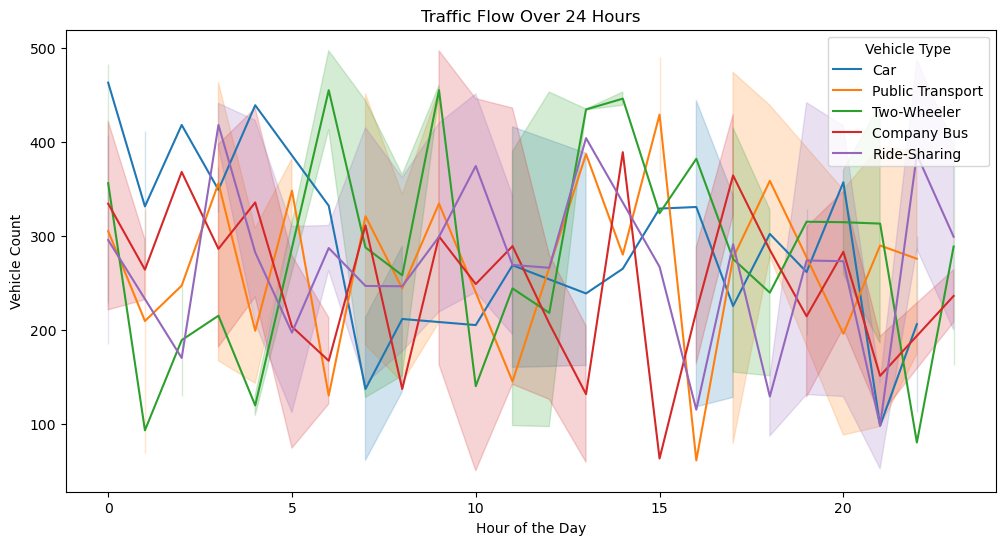

In [25]:
# Plot traffic flow over 24 hours
plt.figure(figsize=(12, 6))
sns.lineplot(data=traffic_flow, x='Hour', y='Vehicle_Count', hue='Vehicle_Type')
plt.title('Traffic Flow Over 24 Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Vehicle Count')
plt.legend(title='Vehicle Type')
plt.show()

### 2. Peak Hour Analysis

In [61]:
hourly_traffic = traffic_flow.groupby('Hour')['Vehicle_Count'].sum().reset_index()
print(hourly_traffic)

    Hour  Vehicle_Count
0      0           3742
1      1           2243
2      2           1581
3      3           4534
4      4           3464
5      5           1897
6      6           2280
7      7           4367
8      8           2303
9      9           3708
10    10           2214
11    11           2555
12    12           1540
13    13           2639
14    14           1826
15    15           1841
16    16           2209
17    17           4028
18    18           2170
19    19           3219
20    20           3534
21    21           2717
22    22           2643
23    23           2513


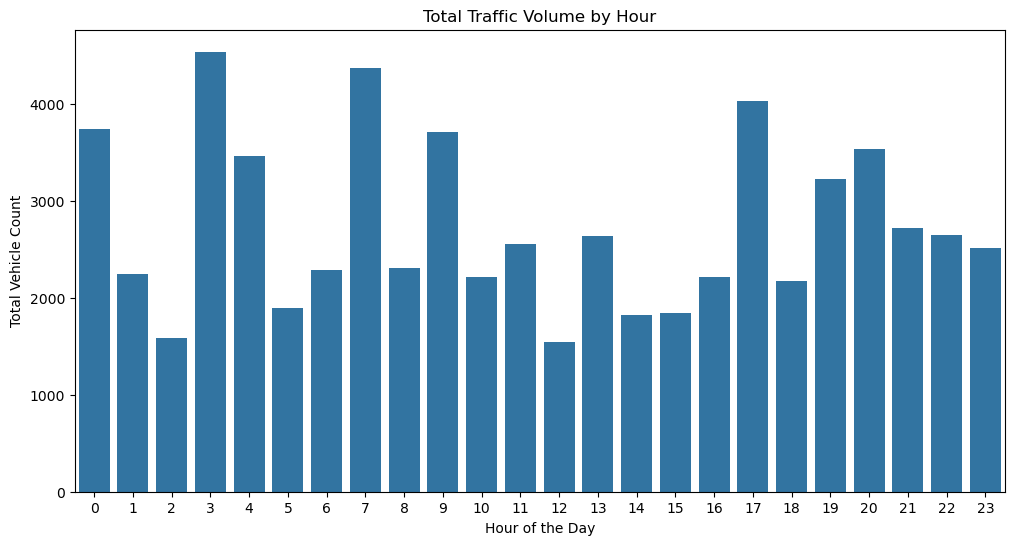

In [28]:
# Calculate total traffic per hour
hourly_traffic = traffic_flow.groupby('Hour')['Vehicle_Count'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_traffic, x='Hour', y='Vehicle_Count')
plt.title('Total Traffic Volume by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Vehicle Count')
plt.show()

## 3. Signal Timing Analysis

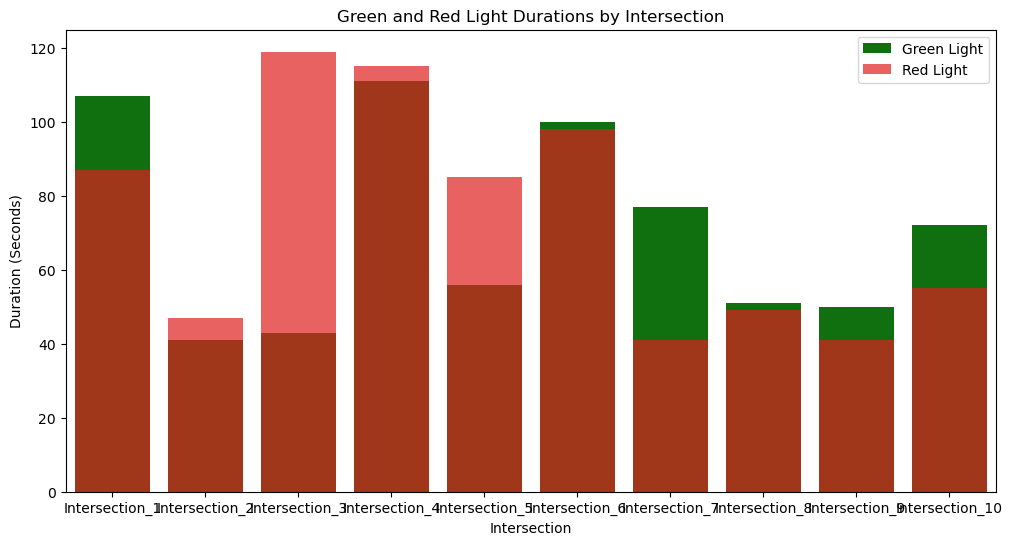

In [53]:
# Plot green and red light durations by intersection
plt.figure(figsize=(12, 6))
sns.barplot(data=signal_timings, x='Intersection', y='Green_Light_Duration', color='green', label='Green Light')
sns.barplot(data=signal_timings, x='Intersection', y='Red_Light_Duration', color='red', label='Red Light', alpha=0.7)  
plt.title('Green and Red Light Durations by Intersection')
plt.xlabel('Intersection')
plt.ylabel('Duration (Seconds)')
plt.legend()
plt.show()

## 4. Correlation Between Traffic Flow and Signal Timings


In [34]:
# Calculate average traffic flow per intersection
avg_traffic_per_intersection = traffic_flow.groupby('Intersection')['Vehicle_Count'].mean().reset_index()

In [36]:
# Merge with signal timings
signal_traffic_correlation = pd.merge(avg_traffic_per_intersection, signal_timings, on='Intersection', how='left')

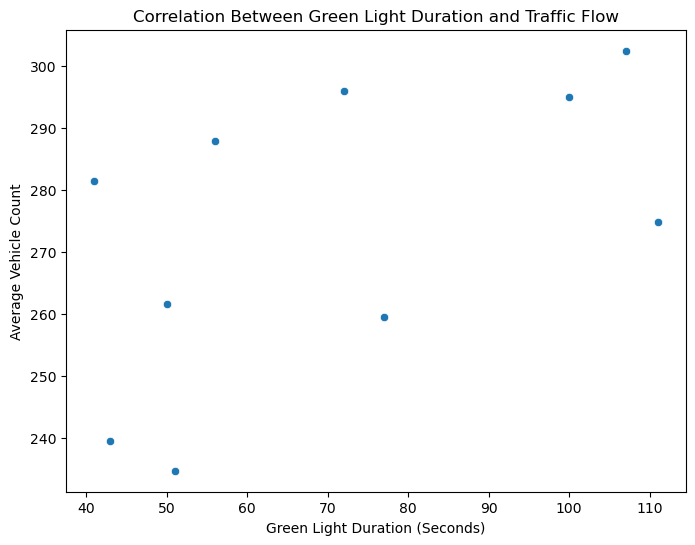

In [38]:
# Plot correlation between traffic flow and green light duration
plt.figure(figsize=(8, 6))
sns.scatterplot(data=signal_traffic_correlation, x='Green_Light_Duration', y='Vehicle_Count')
plt.title('Correlation Between Green Light Duration and Traffic Flow')
plt.xlabel('Green Light Duration (Seconds)')
plt.ylabel('Average Vehicle Count')
plt.show()

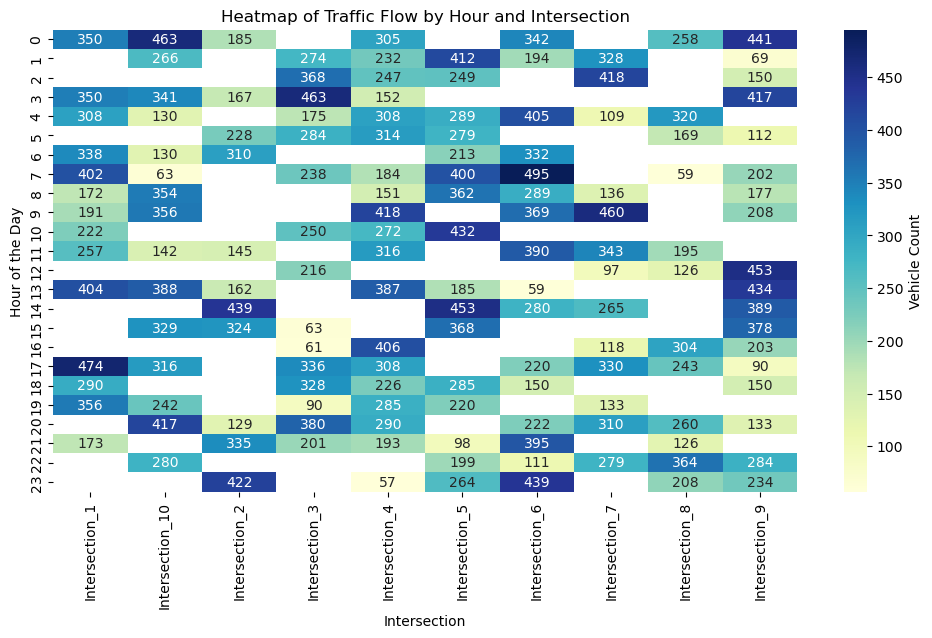

In [179]:
heatmap_data = merged_data.pivot_table(
    index='Hour', 
    columns='Intersection', 
    values=['Vehicle_Count', 'Green_Light_Duration'],
    aggfunc='mean'  # Use the mean to handle multiple rows for the same hour and intersection
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data['Vehicle_Count'], annot=True, cmap='YlGnBu', fmt=".0f", cbar_kws={'label': 'Vehicle Count'})
plt.title('Heatmap of Traffic Flow by Hour and Intersection')
plt.xlabel('Intersection')
plt.ylabel('Hour of the Day')
plt.show()

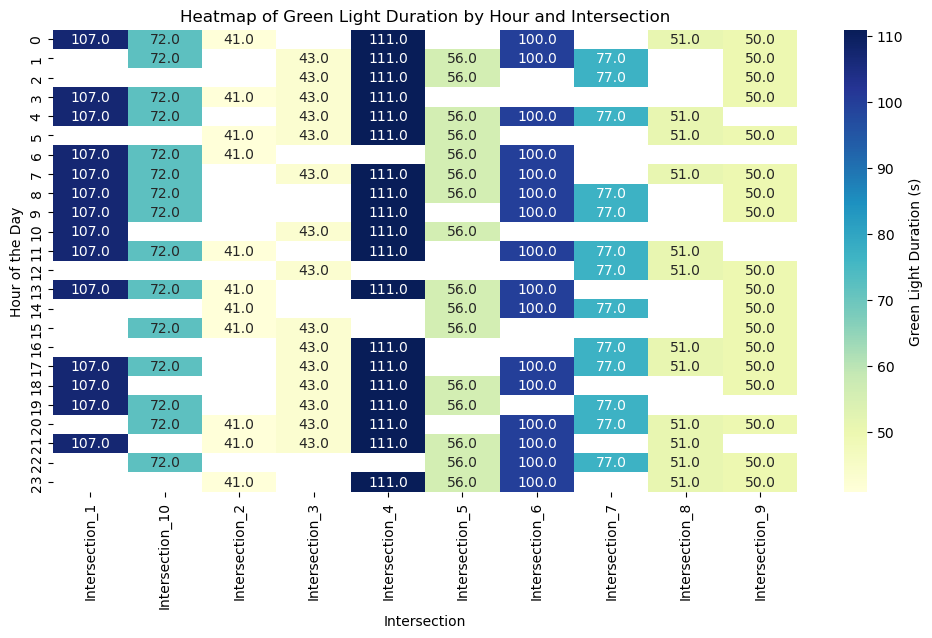

In [181]:
# Create a heatmap for green light duration
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data['Green_Light_Duration'], annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': 'Green Light Duration (s)'})
plt.title('Heatmap of Green Light Duration by Hour and Intersection')
plt.xlabel('Intersection')
plt.ylabel('Hour of the Day')
plt.show()

## Optimization Suggestions

In [41]:
# 1. Adjust Signal Timings Based on Traffic Flow
# Identify intersections with high traffic but low green light duration
high_traffic_intersections = signal_traffic_correlation[signal_traffic_correlation['Vehicle_Count'] > signal_traffic_correlation['Vehicle_Count'].median()]
low_green_intersections = high_traffic_intersections[high_traffic_intersections['Green_Light_Duration'] < high_traffic_intersections['Green_Light_Duration'].median()]

print("\nIntersections with High Traffic but Low Green Light Duration:")
print(low_green_intersections[['Intersection', 'Vehicle_Count', 'Green_Light_Duration']])


Intersections with High Traffic but Low Green Light Duration:
     Intersection  Vehicle_Count  Green_Light_Duration
2  Intersection_2     281.411765                    41
5  Intersection_5     287.863636                    56


In [43]:
# 2. Implement Adaptive Traffic Control Systems
# Suggest intersections for adaptive traffic control
adaptive_control_candidates = low_green_intersections['Intersection'].tolist()
print("\nSuggested Intersections for Adaptive Traffic Control Systems:")
print(adaptive_control_candidates)


Suggested Intersections for Adaptive Traffic Control Systems:
['Intersection_2', 'Intersection_5']


In [45]:
# 3. Promote Public Transport and Ride-Sharing
# Analyze the proportion of public transport and ride-sharing vehicles
public_transport_flow = traffic_flow[traffic_flow['Vehicle_Type'].isin(['Public Transport', 'Ride-Sharing Services'])]
public_transport_percentage = public_transport_flow['Vehicle_Count'].sum() / traffic_flow['Vehicle_Count'].sum() * 100

print(f"\nPercentage of Public Transport and Ride-Sharing Vehicles: {public_transport_percentage:.2f}%")
if public_transport_percentage < 30:
    print("Consider promoting public transport and ride-sharing to reduce private vehicle usage.")


Percentage of Public Transport and Ride-Sharing Vehicles: 19.16%
Consider promoting public transport and ride-sharing to reduce private vehicle usage.


##  Predicting Traffic Flow (using existing features)

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Assuming hourly_traffic contains 'Hour' and 'Vehicle_Count'
# Features and target variable
X = hourly_traffic[['Hour']]  # Feature: Hour
y = hourly_traffic['Vehicle_Count']  # Target: Vehicle_Count

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the traffic flow for each hour from 0 to 24
hourly_predictions = []

for hour in range(25):  # Loop through hours 0 to 24
    # Predict the vehicle count for each hour
    predicted_flow = model.predict([[hour]])
    hourly_predictions.append(predicted_flow[0])




C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: U

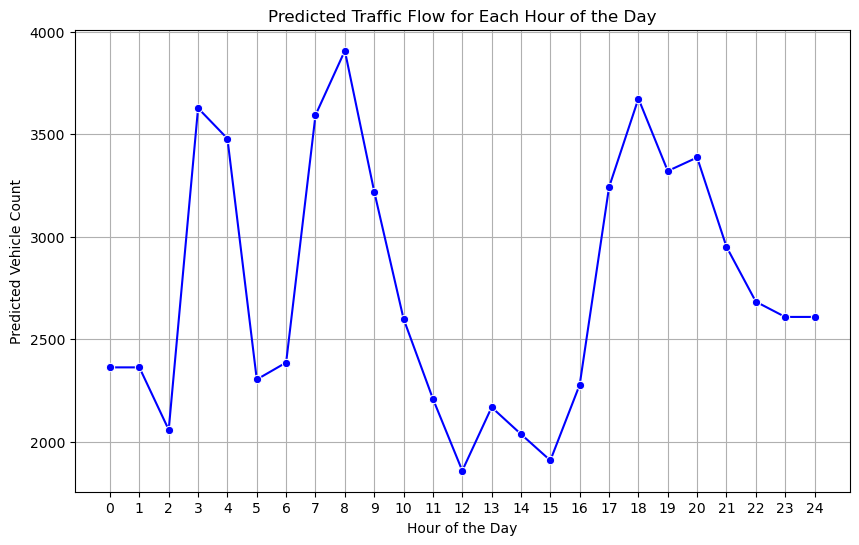

In [129]:
# Plot the predicted traffic flow as a line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(25), y=hourly_predictions, marker='o', color='b')

# Adding titles and labels
plt.title('Predicted Traffic Flow for Each Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Predicted Vehicle Count')
plt.xticks(range(25))  # Ensure x-axis has values from 0 to 24
plt.grid(True)
plt.show()

## Optimizing Signal Timings Dynamically

In [173]:
# Calculate the mean and standard deviation of Vehicle_Count
mean_traffic = hourly_traffic['Vehicle_Count'].mean()

# Calculate the standard deviations of green and red light durations from signal_timings data
std_green_duration = signal_timings['Green_Light_Duration'].std()
std_red_duration = signal_timings['Red_Light_Duration'].std()

# Calculate the mean green light and red light durations
mean_green_duration = signal_timings['Green_Light_Duration'].mean()
mean_red_duration = signal_timings['Red_Light_Duration'].mean()

# Calculate the standard deviation of predicted traffic flow
std_predicted_flow = hourly_traffic['Vehicle_Count'].std()

# Initialize a dictionary to store the optimized signal timings
optimized_signal_timings = {}

# Iterate over each hour from 0 to 24
for hour in range(25):
    predicted_flow = hourly_predictions[hour]  # Predicted traffic flow for the hour
    
    # Check if the hour exists in the hourly_traffic DataFrame
    hour_data = hourly_traffic[hourly_traffic['Hour'] == hour]
    if hour_data.empty:
        continue  # Skip this hour if no data is available for it
    
    # Get the current vehicle count for the specific hour
    current_vehicle_count = hour_data['Vehicle_Count'].values[0]
    
    # Adjust the green light duration based on traffic conditions
    if predicted_flow > current_vehicle_count + std_predicted_flow:
        # High traffic - increase green light duration
        green_light_duration = mean_green_duration + 1.5*std_green_duration
    elif predicted_flow < current_vehicle_count - std_predicted_flow:
        # Low traffic - decrease green light duration
        green_light_duration = mean_green_duration - 1*std_green_duration
    else:
        # Normal traffic - keep the default green light duration
        green_light_duration = mean_green_duration + 0.5*std_green_duration

    # Adjust red light duration similarly based on standard deviation
    if predicted_flow > current_vehicle_count + std_predicted_flow:
        # High traffic - increase red light duration
        red_light_duration = mean_red_duration + 1.5*std_red_duration
    elif predicted_flow < current_vehicle_count - std_predicted_flow:
        # Low traffic - decrease red light duration
        red_light_duration = mean_red_duration - 1*std_red_duration
    else:
        # Normal traffic - keep the default red light duration
        red_light_duration = mean_red_duration + 0.5*std_red_duration

    # Store the optimized timings
    optimized_signal_timings[hour] = {
        'Green Light Duration (seconds)': green_light_duration,
        'Red Light Duration (seconds)': red_light_duration
    }

# Calculate the overall optimum time for green light and red light durations
optimum_green_duration = sum(timing['Green Light Duration (seconds)'] for timing in optimized_signal_timings.values()) / 25
optimum_red_duration = sum(timing['Red Light Duration (seconds)'] for timing in optimized_signal_timings.values()) / 25

# Display the optimized signal timings for each hour
print("\nOptimized Signal Timings for Each Hour:")
for hour, timings in optimized_signal_timings.items():
    print(f"Hour {hour}: Green Light = {timings['Green Light Duration (seconds)']}s, Red Light = {timings['Red Light Duration (seconds)']}s")


Optimized Signal Timings for Each Hour:
Hour 0: Green Light = 43.87706471343727s, Red Light = 43.033152174448134s
Hour 1: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 2: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 3: Green Light = 43.87706471343727s, Red Light = 43.033152174448134s
Hour 4: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 5: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 6: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 7: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 8: Green Light = 111.18440292984408s, Red Light = 119.70027173832781s
Hour 9: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 10: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 11: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hour 12: Green Light = 84.26146764328136s, Red Light = 89.03342391277593s
Hou

In [175]:
# Display the optimum green and red light durations
print("\nOptimum Green Light Duration: {:.2f} seconds".format(optimum_green_duration))
print("Optimum Red Light Duration: {:.2f} seconds".format(optimum_red_duration))


Optimum Green Light Duration: 79.81 seconds
Optimum Red Light Duration: 84.25 seconds
